## Lab Practice Ensemble learning 1.5:  STACKING (CLASSWORK)  | Machine Learning II
#### ESU  Jan-2025
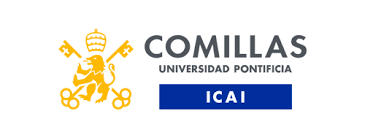

LEARNING OBJECTIVES
- How to run stacking with regression models

---
## Import modules

In [1]:
import numpy as np # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt
import seaborn as sns  # plotting

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

#from sklearn import metrics
#from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.inspection import permutation_importance

from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor

from sklearn.linear_model  import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# solve problems with size and fonts in figures 
plt.rcParams['figure.dpi'] = 75

# auxiliary functions
import utils_ml1 as uml1
import utils_regression_ml2 as urml2
import utils_classification_ml2 as ucml2

# stacking
from sklearn.ensemble import VotingRegressor, StackingRegressor

Useful functions

In [2]:
def compute_mse_mae(model_name, y_train, y_train_est, y_test, y_test_est, y_true_tts, y_tts, y_tts_est):

    # errors
    mse_tr = mean_squared_error(y_train_est, y_train)
    mse_ts = mean_squared_error(y_test_est, y_test)
    mse_tts = mean_squared_error(y_tts_est, y_tts)

    mae_tr = mean_absolute_error(y_train_est, y_train)
    mae_ts = mean_absolute_error(y_test_est, y_test)
    mae_tts = mean_absolute_error(y_tts_est, y_tts)

    mse_true_tts = mean_squared_error(y_tts_est, y_true_tts)
    mae_true_tts = mean_absolute_error(y_tts_est, y_true_tts)

    print(f'MSE(TR, {model_name}) = {mse_tr}')
    print(f'MSE(TS, {model_name}) = {mse_ts}')
    print(f'MSE(TTS, {model_name}) = {mse_tts}')
    print(f'MSE(TTS_true, {model_name}) = {mse_true_tts}')

    print(f'MAE(TR, {model_name}) = {mae_tr}')
    print(f'MAE(TS, {model_name}) = {mae_ts}')
    print(f'MAE(TTS, {model_name}) = {mae_tts}')
    print(f'MAE(TTS_true, {model_name}) = {mae_true_tts}')


    dic_mse_sets = {
        'model_name': model_name,
        'mse_tr': mse_tr,
        'mse_ts': mse_ts,
        'mse_tts': mse_tts,
        'mse_true_tts': mse_true_tts,
    }

    df_mse_sets = pd.DataFrame([dic_mse_sets])

    return df_mse_sets

---
##  1. Regression problem

#### 1.1 Set the synthetic problem

In [3]:
# Synthetic problem
np.random.RandomState(9999)

n = 1000
X = np.random.uniform(0, 10.0, size=n)

y_true_left = X * np.sin(X)
y_true_right = X * np.sin(2*X)

# add a step
y_true = y_true_left
y_true[X>6] = 15 - y_true_right[X>6]

# add noise
noise =  0.5 * (1 + X**0.8) * np.random.normal(scale=1, loc=0, size=n)
y = y_true + noise

#sort the inputs for easy plotting
idx = np.argsort(X)
X = X[idx]
y_true = y_true[idx]
y = y[idx]

#### 1.2 Split the dataset in TR and TS and plot the problem

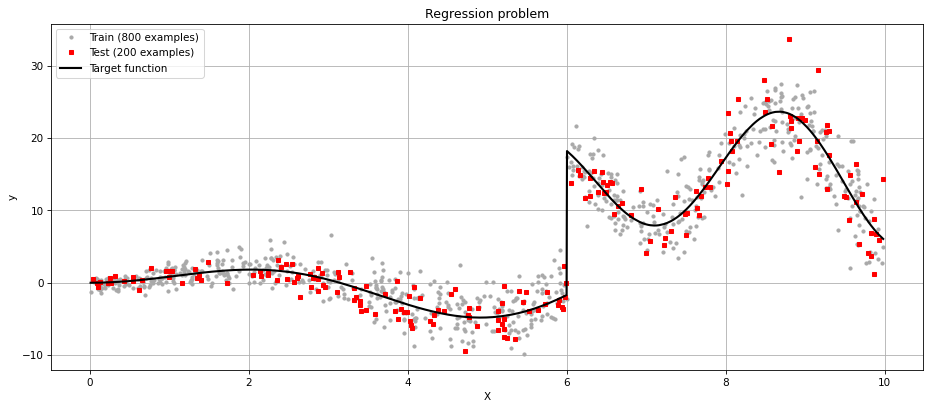

In [4]:
# Split the dataset in TR and TS
 
# Define input and output matrices
INPUTS = ['X']
OUTPUT = 'Y'

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0) #seed for replication

#sort the inputs for easy plotting
idx = np.argsort(X_train)
X_train = X_train[idx]
y_train = y_train[idx]

idx = np.argsort(X_test)
X_test = X_test[idx]
y_test = y_test[idx]

# 2D-array versions to feed models
X_train = X_train[:, np.newaxis]
X_test = X_test[:, np.newaxis]

# Plot data
plt.figure(figsize=(15, 6))
plt.plot(X_train,y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X_test,y_test,'sr', markersize = 4, label=f'Test ({len(X_test)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.title('Regression problem')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.grid()
plt.show()

### 1.3 True Test Set (TTS) - large sample without noise

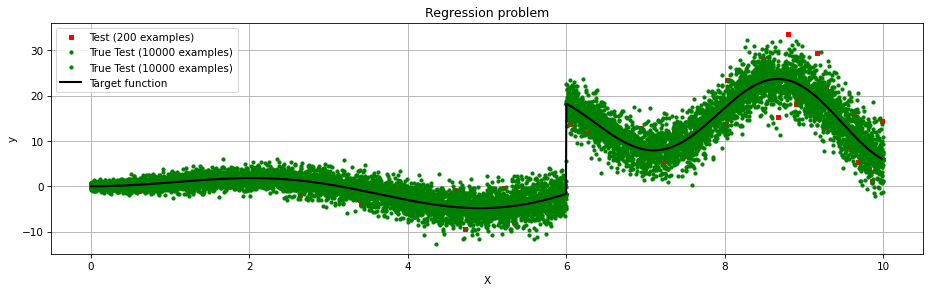

In [6]:
#### Tiene muchos datos: 10000 puntos: mismo nivel de ruido. Es para conocer el error real.

### y_true_tts: muestra muy grande sin ruido
### y_tts: muestra muy grande con ruido
n_tts = 10000
X_tts = np.random.uniform(0, 10.0, size=n_tts)

y_true_left_tts = X_tts * np.sin(X_tts)
y_true_right_tts = X_tts * np.sin(2*X_tts)

# add a step
y_true_tts = y_true_left_tts
y_true_tts[X_tts>6] = 15 - y_true_right_tts[X_tts>6]

# add noise
noise_tts =  0.5 * (1 + X_tts**0.8) * np.random.normal(scale=1, loc=0, size=n_tts)
y_tts = y_true_tts + noise_tts


#sort the inputs for easy plotting
idx_tts = np.argsort(X_tts)
X_tts = X_tts[idx_tts][:, np.newaxis]
y_true_tts = y_true_tts[idx_tts]
y_tts = y_tts[idx_tts]

# Plot data
plt.figure(figsize=(15, 4))
plt.plot(X_test,y_test,'sr', markersize = 4, label=f'Test ({len(X_test)} examples)')
plt.plot(X_tts, y_true_tts,'.', color='green', label=f'True Test ({len(X_tts)} examples)')
plt.plot(X_tts, y_tts,'.', color='green', label=f'True Test ({len(X_tts)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.title('Regression problem')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.grid()
plt.show()

In [7]:
# Create a dataframe with the mse results o be populated with each model
df_mse_results = pd.DataFrame()

---
## 2 Polynomial model

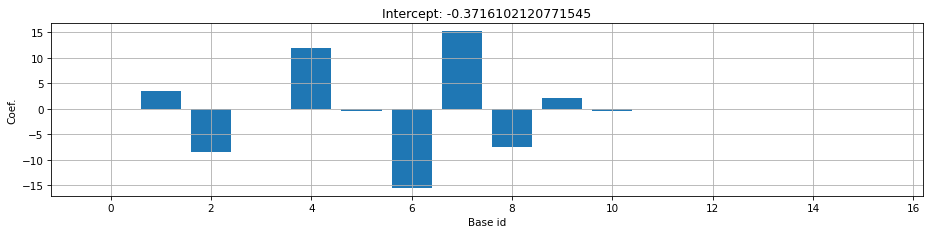

In [8]:
##### Ajustar un polinomio.
# First, create the basis functions using SplineTransformer
degree = 15 # order of the basis polynomials

## PolynomialFeatures(degree=degree).fit(X_train) crea una matriz con las potencias de X hasta el grado degree. [1, x, x**2]
plf = PolynomialFeatures(degree=degree).fit(X_train)
# X_train_plf contiene en la primera columna, valores ^0 de los dtaos, en la segunda los valores de los datos y en la tercera los valores al cuadrado.
X_train_plf = plf.transform(X_train)

# fit the poly using ridge regression
##### ¿Que hace ridge regression? Al error se le penaliza con el valor de los parametros al cuadrado.    
ridge_plf = Ridge(alpha=0.1)
ridge_plf.fit(X_train_plf, y_train)

""" using CV
ridge_plf = RidgeCV(alphas=alphas=[1e-3, 1e-2, 1e-1, 1])
ridge_plf.fit(X_train_plf, y_train) """

# show coefs
plt.figure(figsize=(15, 3))
plt.bar(range(degree+1), ridge_plf.coef_)
plt.title(f'Intercept: {ridge_plf.intercept_}')
plt.xlabel('Base id')
plt.ylabel('Coef.')
plt.grid()
plt.show()

###### Pintamos el coeficiente para cada orden. (es una medida de la importancia de cada orden)

#### 2.1 Compute errors of the polynomial

MSE(TR, poly) = 9.817599278057067
MSE(TS, poly) = 10.826179023466164
MSE(TTS, poly) = 10.934652524396734
MSE(TTS_true, poly) = 5.030716264710763
MAE(TR, poly) = 2.2936771882224045
MAE(TS, poly) = 2.4059283297589356
MAE(TTS, poly) = 2.35953565279483
MAE(TTS_true, poly) = 1.3428523097999037


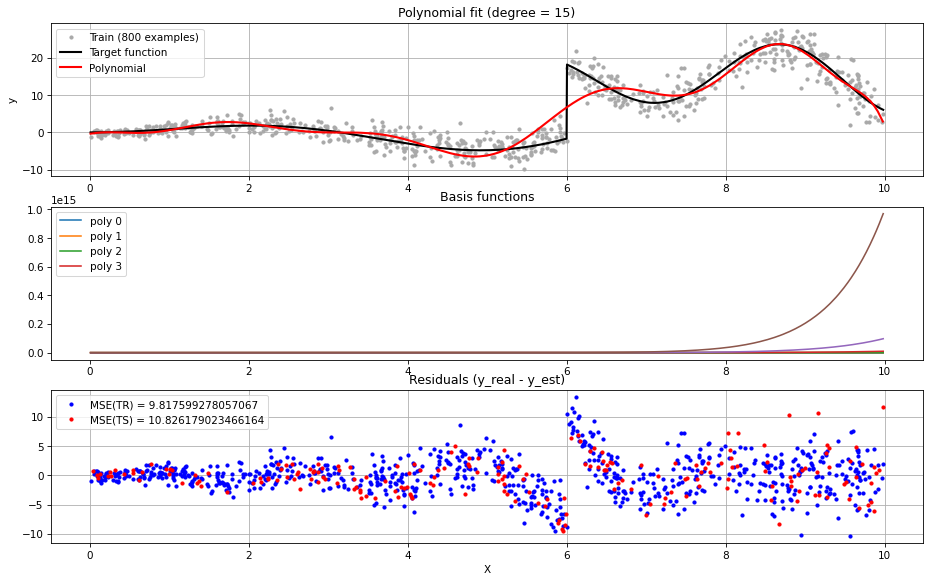

In [9]:
# estimations using the poly
y_train_poly = ridge_plf.predict(X_train_plf)

X_test_plf = plf.transform(X_test)
y_test_poly = ridge_plf.predict(X_test_plf)

X_tts_plf = plf.transform(X_tts)
y_tts_poly = ridge_plf.predict(X_tts_plf)

# errors
df_mse_results = pd.concat([df_mse_results,
                             compute_mse_mae('poly', y_train, y_train_poly, y_test, y_test_poly, y_true_tts, y_tts, y_tts_poly)],
                             ignore_index=True)

# Plot data
plt.figure(figsize=(15, 9))
ax1 = plt.subplot(3,1,1)
plt.plot(X_train,y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.plot(X_train, y_train_poly, '-', color = 'red', linewidth=2, label='Polynomial')
plt.grid()
plt.legend()
plt.title(f'Polynomial fit (degree = {degree})')
plt.ylabel('y')

# plot basis
plt.subplot(3,1,2, sharex = ax1)
plt.plot(X, plf.transform(X[:, np.newaxis]))
plt.legend([f"poly {n}" for n in range(4)])
plt.title('Basis functions')


# plot residuals
mse_tr = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_tr'].values[0]
mse_ts = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_ts'].values[0]
plt.subplot(3,1,3, sharex = ax1)
plt.plot(X_train, y_train - y_train_poly, '.', color = 'blue', label=f'MSE(TR) = {mse_tr}')
plt.plot(X_test, y_test- y_test_poly, '.', color = 'red', label=f'MSE(TS) = {mse_ts}')
plt.title(f'Residuals (y_real - y_est)')
plt.legend()
plt.grid()
plt.xlabel('X')
plt.show()

#### El problema esta en el salto. Con el TTS tenemos el salto muy bien modelado. Los 200 puntos que tengo es una muestra pequeña y nos puede engañar.

### la segunda grafica son los monomios

### Los residuos aumentan mucho en el salto.

---
## 3. B-spline model

SplineTransformer generates B-spline basis functions. A basis function of a B-spline is a piece-wise polynomial function that is non-zero only between consecutive knots. Given number of knots, this results in matrix of n_samples rows and n_knots + degree - 1 columns:

[[basis_1(x_0), basis_2(x_0), ...],

 [basis_1(x_1), basis_2(x_1), ...],
 
 ...]

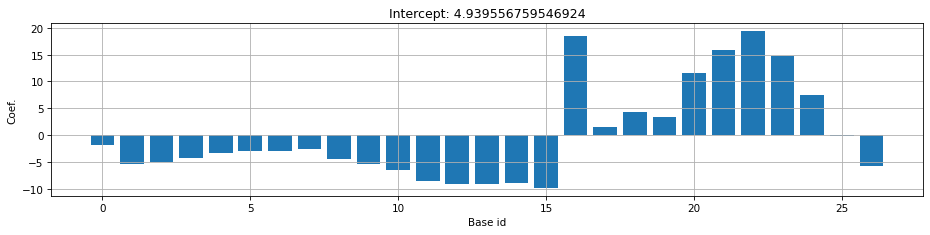

In [10]:
# First, create the basis functions using SplineTransformer
## Dibujamos como se pondera caa funcion base
n_knots = 25 # number of "breaking points"
degree = 3 # order of the basis polynomials

splt = SplineTransformer(n_knots=n_knots, degree=degree).fit(X_train)
X_train_splt = splt.transform(X_train)

# fit the B-spline using ridge regression
ridge_splt = Ridge(alpha=0.1)
ridge_splt.fit(X_train_splt, y_train)

# show coefs
plt.figure(figsize=(15, 3))
plt.bar(range(n_knots+2), ridge_splt.coef_)
plt.title(f'Intercept: {ridge_splt.intercept_}')
plt.xlabel('Base id')
plt.ylabel('Coef.')
plt.grid()
plt.show()

#### 3.1 Compute errors of B-spline

MSE(TR, spline) = 6.777899559713479
MSE(TS, spline) = 8.173234646502763
MSE(TTS, spline) = 7.620848953570094
MSE(TTS_true, spline) = 1.6884564323216023
MAE(TR, spline) = 1.928718942534105
MAE(TS, spline) = 2.0451663042681467
MAE(TTS, spline) = 1.985557393369958
MAE(TTS_true, spline) = 0.5920579500160043


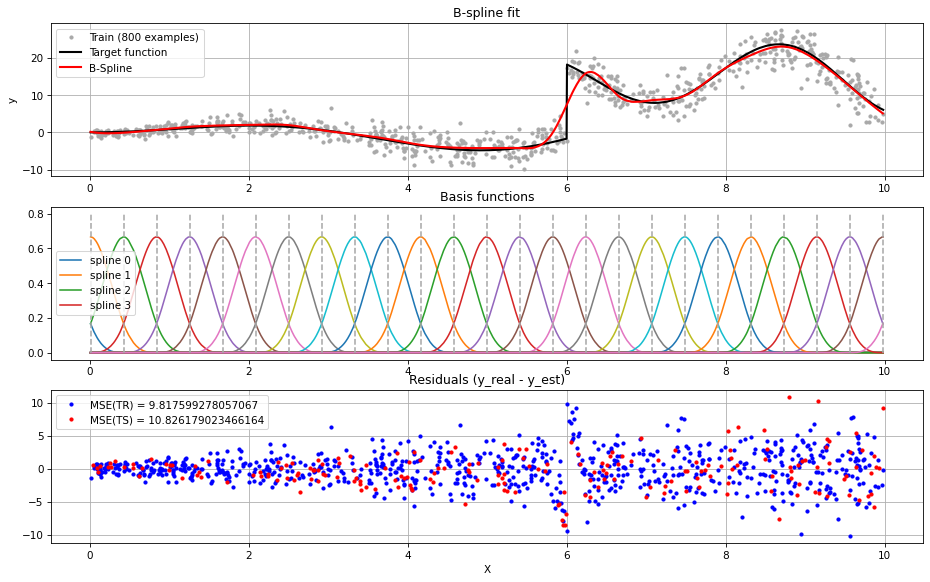

In [11]:
# estimations using the spline
y_train_spline = ridge_splt.predict(X_train_splt)

X_test_splt = splt.transform(X_test)
y_test_spline = ridge_splt.predict(X_test_splt)

X_tts_splt = splt.transform(X_tts)
y_tts_spline = ridge_splt.predict(X_tts_splt)

# errors
df_mse_results = pd.concat([df_mse_results,
                             compute_mse_mae('spline', y_train, y_train_spline, y_test, y_test_spline, y_true_tts, y_tts, y_tts_spline)],
                             ignore_index=True)

# Plot data
plt.figure(figsize=(15, 9))
ax1 = plt.subplot(3,1,1)
plt.plot(X_train,y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.plot(X_train, y_train_spline, '-', color = 'red', linewidth=2, label='B-Spline')
plt.grid()
plt.legend()
plt.title('B-spline fit')
plt.ylabel('y')

# plot basis with the knots of the spline
plt.subplot(3,1,2, sharex = ax1)
plt.plot(X, splt.transform(X[:, np.newaxis]))
plt.legend([f"spline {n}" for n in range(4)])
plt.title('Basis functions')

knots = splt.bsplines_[0].t
plt.vlines(knots[degree:-degree], color = 'darkgray', ymin=0, ymax=0.8, linestyles="dashed")

# plot residuals
mse_tr = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_tr'].values[0]
mse_ts = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_ts'].values[0]

plt.subplot(3,1,3, sharex = ax1)
plt.plot(X_train, y_train - y_train_spline, '.', color = 'blue', label=f'MSE(TR) = {mse_tr}')
plt.plot(X_test, y_test- y_test_spline, '.', color = 'red', label=f'MSE(TS) = {mse_ts}')
plt.title(f'Residuals (y_real - y_est)')
plt.legend()
plt.grid()
plt.xlabel('X')
plt.show()

---
## 4. Simple regression tree

In [12]:
# grid in min_impurity x min_samples_leaf x min_samples_split
param = {'DT__min_impurity_decrease': np.arange(0, 0.001 * np.var(y_train),0.001), # Minimum impurity to decrease in each split
         'DT__min_samples_leaf': np.arange(1,10,1), # Minimum number of obs in a terminal node
         'DT__min_samples_split':  np.arange(2,10,1)} # Minimum number of obs in node to keep cutting

pipe = Pipeline(steps=[('DT', DecisionTreeRegressor(criterion='squared_error',  # impurity measure: variance reduction
                                                     random_state=150))]) # For replication
                                                     
# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
single_reg_tree_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       cv=nFolds) # Number of Folds 
                       
single_reg_tree_fit.fit(X_train.reshape(-1, 1), y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('DT',
                                        DecisionTreeRegressor(random_state=150))]),
             n_jobs=-1,
             param_grid={'DT__min_impurity_decrease': array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
       0.018, 0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026,
       0.027, 0.028, 0.029, 0.03 , 0.031, 0.032, 0.033, 0...
       0.036, 0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044,
       0.045, 0.046, 0.047, 0.048, 0.049, 0.05 , 0.051, 0.052, 0.053,
       0.054, 0.055, 0.056, 0.057, 0.058, 0.059, 0.06 , 0.061, 0.062,
       0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07 , 0.071,
       0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079]),
                         'DT__min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'DT__min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9])})

Compute errors of regression tree

MSE(TR, regtree) = 4.778436426362367
MSE(TS, regtree) = 7.9768733282435305
MSE(TTS, regtree) = 7.087639195953825
MSE(TTS_true, regtree) = 1.100941440645954
MAE(TR, regtree) = 1.6201324211694939
MAE(TS, regtree) = 2.049158349716606
MAE(TTS, regtree) = 1.965038990754856
MAE(TTS_true, regtree) = 0.7551876586343562


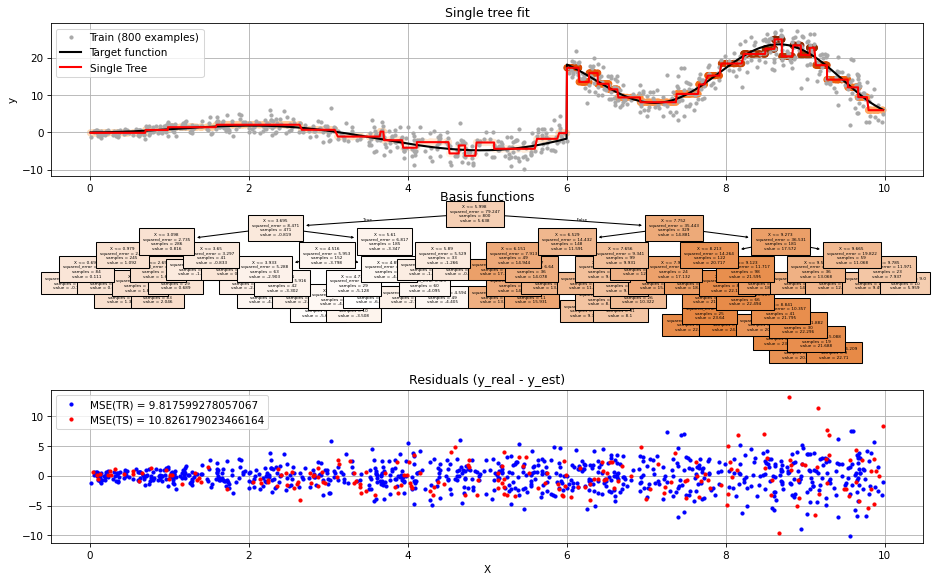

In [13]:
# estimations using the spline
y_train_regtree = single_reg_tree_fit.best_estimator_['DT'].predict(X_train)
y_test_regtree = single_reg_tree_fit.best_estimator_['DT'].predict(X_test)
y_tts_regtree = single_reg_tree_fit.best_estimator_['DT'].predict(X_tts)

# errors
df_mse_results = pd.concat([df_mse_results,
                             compute_mse_mae('regtree', y_train, y_train_regtree, y_test, y_test_regtree, y_true_tts, y_tts, y_tts_regtree)],
                             ignore_index=True)
# Plot data
plt.figure(figsize=(15, 9))
ax1 = plt.subplot(3,1,1)
plt.plot(X_train,y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.plot(X_train, y_train_regtree, '-', color = 'red', linewidth=2, label='Single Tree')
plt.scatter(X_train, y_train_regtree, c = y_train_regtree, cmap='Oranges')
plt.grid()
plt.legend()
plt.title('Single tree fit')
plt.ylabel('y')

# plot basis with the knots of the spline
plt.subplot(3,1,2, sharex = ax1)
plot_tree(single_reg_tree_fit.best_estimator_['DT'],
          feature_names= ['X'],
          fontsize=4, filled=True)
plt.title('Basis functions')

# plot residuals
mse_tr = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_tr'].values[0]
mse_ts = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_ts'].values[0]

plt.subplot(3,1,3, sharex = ax1)
plt.plot(X_train, y_train - y_train_regtree, '.', color = 'blue', label=f'MSE(TR) = {mse_tr}')
plt.plot(X_test, y_test- y_test_regtree, '.', color = 'red', label=f'MSE(TS) = {mse_ts}')
plt.title(f'Residuals (y_real - y_est)')
plt.legend()
plt.grid()
plt.xlabel('X')
plt.show()



#### El primer corte, 

---
### 5. Neural Network (MLP)

In [14]:
### para saber el numero de neuronas, hay que estudiar los puntos de crecimiento y decrecimiento de la funcion
### Cada neurona es una 
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))

In [16]:
n_neurons_first_layer = 10
mlp = MLPRegressor(hidden_layer_sizes=(n_neurons_first_layer,),  # 1 hidden layer
                   activation='logistic',  # activation function (try 'relu', 'logistic')
                   solver='lbfgs',  # Optimization algorithm ('lbfgs', 'sgd', 'adam')
                   alpha=0.001,  # L2 regularization (0.01)
                   max_iter=10000,  # number of iterations
                   random_state=42)

mlp.fit(X_train_scaled, y_train_scaled.ravel())  # fit

# MLP params
weights = mlp.coefs_
biases = mlp.intercepts_

output_weights = mlp.coefs_[1]

In [17]:
# Activation functions (for plotting)
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

MSE(TR, mlp) = 7.072111391683995
MSE(TS, mlp) = 7.521152806347677
MSE(TTS, mlp) = 7.292901140563523
MSE(TTS_true, mlp) = 1.2897515678552873
MAE(TR, mlp) = 2.036006804918369
MAE(TS, mlp) = 2.0442484169938853
MAE(TTS, mlp) = 2.0681464869750554
MAE(TTS_true, mlp) = 0.937996005474903


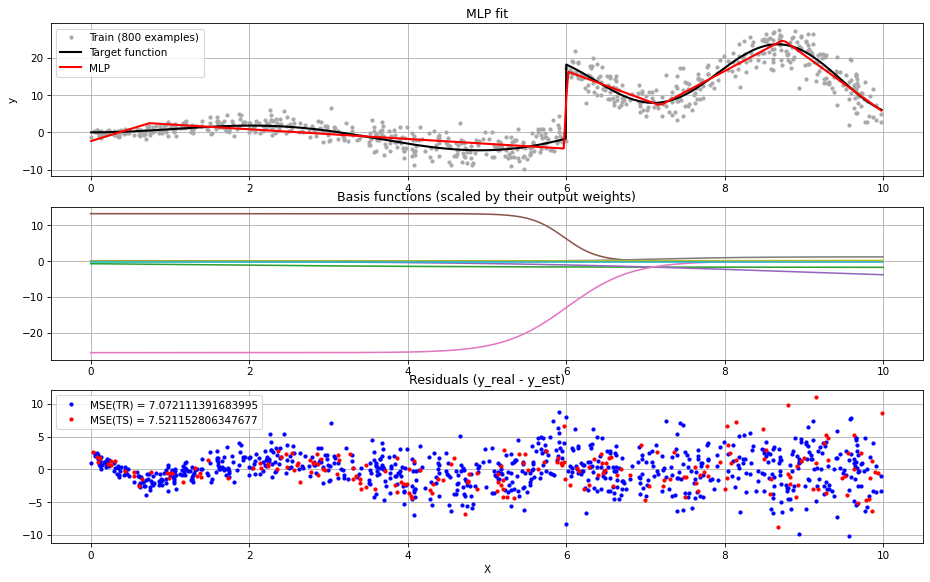

In [19]:
# estimations using the mlp

X_test_scaled = scaler_x.transform(X_test)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))
X_tts_scaled = scaler_x.transform(X_tts)

y_train_mlp_scaled = mlp.predict(X_train_scaled)
y_train_mlp = scaler_y.inverse_transform(y_train_mlp_scaled.reshape(-1, 1))  # Desescalar predicciones

y_test_mlp_scaled = mlp.predict(X_test_scaled)
y_test_mlp = scaler_y.inverse_transform(y_test_mlp_scaled.reshape(-1, 1))  # Desescalar predicciones

y_tts_mlp_scaled = mlp.predict(X_tts_scaled)
y_tts_mlp = scaler_y.inverse_transform(y_tts_mlp_scaled.reshape(-1, 1))  # Desescalar predicciones

# error
df_mse_results = pd.concat([df_mse_results,
                             compute_mse_mae('mlp', y_train, y_train_mlp, y_test, y_test_mlp, y_true_tts, y_tts, y_tts_mlp)],
                             ignore_index=True)

# Plot data
plt.figure(figsize=(15,9))
ax1 = plt.subplot(3,1,1)
plt.plot(X_train, y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.plot(X_train, y_train_mlp, '-', color = 'red', linewidth=2, label='MLP')
plt.grid()
plt.legend()
plt.title('MLP fit')
plt.ylabel('y')

# plot activation functions of the neurons
plt.subplot(3,1,2, sharex = ax1)

X_range = np.linspace(0, 10, 1000).reshape(-1, 1)
X_scaled_range = scaler_x.transform(X_range)
hidden_activations_sigmoid = sigmoid(X_scaled_range @ weights[0] + biases[0])

for i in range(hidden_activations_sigmoid.shape[1]):  # Iterar sobre cada neurona
    plt.plot(X_range, output_weights[i] * hidden_activations_sigmoid[:, i], label=f'Neuron {i+1}')

plt.grid()
plt.title('Basis functions (scaled by their output weights)')

# plot residuals
mse_tr = df_mse_results.loc[df_mse_results['model_name'] == 'mlp', 'mse_tr'].values[0]
mse_ts = df_mse_results.loc[df_mse_results['model_name'] == 'mlp', 'mse_ts'].values[0]
plt.subplot(3,1,3, sharex = ax1)
plt.plot(X_train, y_train - y_train_mlp.ravel(), '.', color = 'blue', label=f'MSE(TR) = {mse_tr}')
plt.plot(X_test, y_test - y_test_mlp.ravel(), '.', color = 'red', label=f'MSE(TS) = {mse_ts}')
plt.title(f'Residuals (y_real - y_est)')
plt.legend()
plt.grid()
plt.xlabel('X')
plt.show()

### La segunda gráfica son las funciones bases pesadas.



---
## 6. Stacking

#### 6.1 First define the estimators to be stacked

In [20]:
# Polinomio para regresión
degree_poly = 15

n_knots_spline = 25 # number of "breaking points"
degree_basis_spline = 3 # order of the basis polynomials

# grid in min_impurity x min_samples_leaf x min_samples_split
param_tree = {'DT__min_impurity_decrease': np.arange(0, 0.001 * np.var(y_train),0.001), # Minimum impurity to decrease in each split
         'DT__min_samples_leaf': np.arange(1,10,1), # Minimum number of obs in a terminal node
         'DT__min_samples_split':  np.arange(1,10,1)} # Minimum number of obs in node to keep cutting

pipe_tree = Pipeline(steps=[('DT', DecisionTreeRegressor(criterion='squared_error',  # impurity measure: variance reduction
                                                         random_state=150))]) # For replication

nFolds_tree = 10

## set of estimators to be stacked
estimators = [
    ('poly', make_pipeline(
        PolynomialFeatures(degree_poly), 
        Ridge(alpha=1e-3))
    ),
    ('spline', make_pipeline(
        SplineTransformer(n_knots=n_knots, degree=degree),
        Ridge(alpha=1e-3))
    ),
    ('regtree', make_pipeline( # aqui lo hacemos con CV.
                GridSearchCV(estimator= pipe_tree,
                            param_grid=param_tree, # Defined grid to search in
                            n_jobs=-1, # Number of cores to use (parallelize)
                            cv=nFolds_tree)) # Number of Folds
    )
]

estimators

[('poly',
  Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=15)),
                  ('ridge', Ridge(alpha=0.001))])),
 ('spline',
  Pipeline(steps=[('splinetransformer', SplineTransformer(n_knots=25)),
                  ('ridge', Ridge(alpha=0.001))])),
 ('regtree',
  Pipeline(steps=[('gridsearchcv',
                   GridSearchCV(cv=10,
                                estimator=Pipeline(steps=[('DT',
                                                           DecisionTreeRegressor(random_state=150))]),
                                n_jobs=-1,
                                param_grid={'DT__min_impurity_decrease': array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
         0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
         0.018, 0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026,
         0.027, 0.02...
         0.036, 0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044,
         0.045, 0.046, 0.047, 0.048, 0.049, 0.05

#### 6.2 Fit the ensemble of stacked models

In [21]:
#### Aquií estamos dando pesos diferentes a cada modelo

weights = [0.1, 0.2, 0.7]
stacked_reg = VotingRegressor(estimators = estimators, weights = weights)
stacked_reg = stacked_reg.fit(X_train, y_train)
stacked_reg.get_params()

/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
7200 fits failed out of a total of 64800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7200 fits failed with the following error:
Traceback (most recent call last):
  File "/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/envs/ML2

{'estimators': [('poly',
   Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=15)),
                   ('ridge', Ridge(alpha=0.001))])),
  ('spline',
   Pipeline(steps=[('splinetransformer', SplineTransformer(n_knots=25)),
                   ('ridge', Ridge(alpha=0.001))])),
  ('regtree',
   Pipeline(steps=[('gridsearchcv',
                    GridSearchCV(cv=10,
                                 estimator=Pipeline(steps=[('DT',
                                                            DecisionTreeRegressor(random_state=150))]),
                                 n_jobs=-1,
                                 param_grid={'DT__min_impurity_decrease': array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
          0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
          0.018, 0.019, 0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026,
          0.027, 0.02...
          0.036, 0.037, 0.038, 0.039, 0.04 , 0.041, 0.042, 0.043, 0.044,
          0.045, 

MSE(TR, stack) = 5.008865562293079
MSE(TS, stack) = 7.553954839130122
MSE(TTS, stack) = 6.885027023358782
MSE(TTS_true, stack) = 0.9170919810090434
MAE(TR, stack) = 1.6654415135507947
MAE(TS, stack) = 1.9819380374962645
MAE(TTS, stack) = 1.9366332915558757
MAE(TTS_true, stack) = 0.6665316839270554


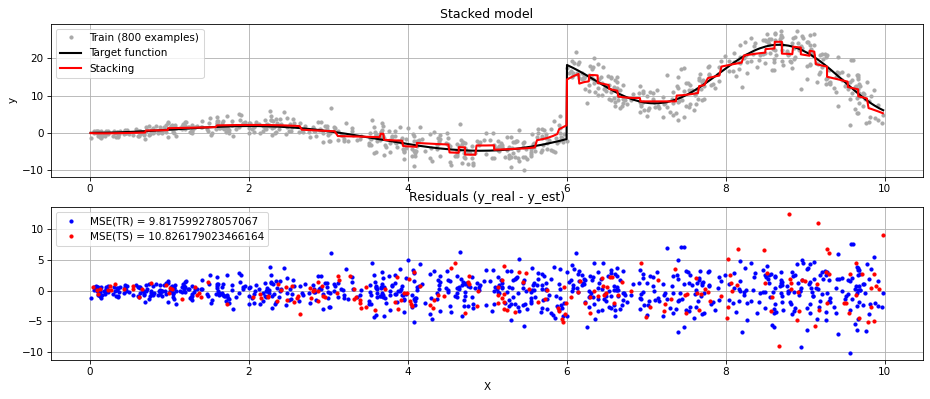

In [22]:
# estimations using the stacked models
y_train_stack = stacked_reg.predict(X_train)
y_test_stack = stacked_reg.predict(X_test)
y_tts_stack = stacked_reg.predict(X_tts)

# errors
df_mse_results = pd.concat([df_mse_results,
                             compute_mse_mae('stack', y_train, y_train_stack, y_test, y_test_stack, y_true_tts, y_tts, y_tts_stack)],
                             ignore_index=True)
# Plot data
plt.figure(figsize=(15, 9))
ax1 = plt.subplot(3,1,1)
plt.plot(X_train,y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.plot(X_train, y_train_stack, '-', color = 'red', linewidth=2, label='Stacking')
plt.grid()
plt.legend()
plt.title('Stacked model')
plt.ylabel('y')

# plot residuals
mse_tr = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_tr'].values[0]
mse_ts = df_mse_results.loc[df_mse_results['model_name'] == 'poly', 'mse_ts'].values[0]

plt.subplot(3,1,2, sharex = ax1)
plt.plot(X_train, y_train - y_train_stack, '.', color = 'blue', label=f'MSE(TR) = {mse_tr}')
plt.plot(X_test, y_test- y_test_stack, '.', color = 'red', label=f'MSE(TS) = {mse_ts}')
plt.title(f'Residuals (y_real - y_est)')
plt.legend()
plt.grid()
plt.xlabel('X')
plt.show()

#### Discontinuidad en los  residuos.


---
## 7. Compare single models with stacked one

In [23]:
#### En Stacking no debes poner modelos malos.


df_mse_results

,model_name,mse_tr,mse_ts,mse_tts,mse_true_tts
0,poly,9.817599,10.826179,10.934653,5.030716
1,spline,6.777900,8.173235,7.620849,1.688456
2,regtree,4.778436,7.976873,7.087639,1.100941
3,mlp,7.072111,7.521153,7.292901,1.289752
4,mlp,7.072111,7.521153,7.292901,1.289752
5,stack,5.008866,7.553955,6.885027,0.917092


In [24]:
df_mse_results.drop(4, inplace=True)
df_mse_results

,model_name,mse_tr,mse_ts,mse_tts,mse_true_tts
0,poly,9.817599,10.826179,10.934653,5.030716
1,spline,6.777900,8.173235,7.620849,1.688456
2,regtree,4.778436,7.976873,7.087639,1.100941
3,mlp,7.072111,7.521153,7.292901,1.289752
5,stack,5.008866,7.553955,6.885027,0.917092


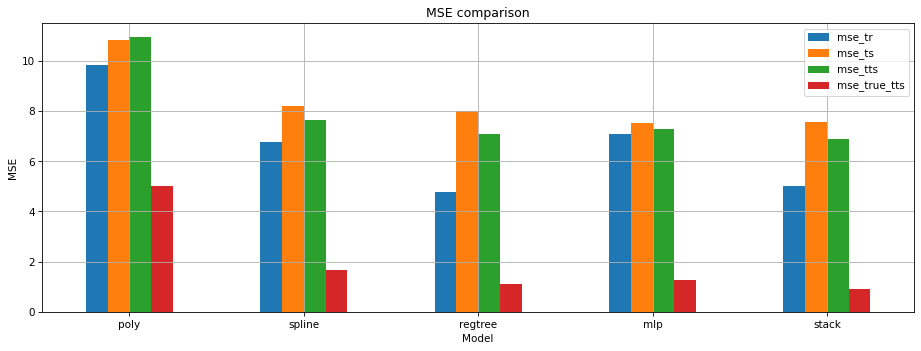

In [25]:
# Plot error data
fig, ax = plt.subplots(figsize=(15, 5))

df_mse_results.set_index("model_name").plot(kind="bar", ax=ax)
ax.set_xlabel("Model")
ax.set_ylabel("MSE")
ax.set_title("MSE comparison")
plt.xticks(rotation=0)
plt.grid()

plt.show()

#### Como vemos, el arbol está muy mal.

### La barra verde es mas fiable en cuanto al error que comete el modelo.



Text(0, 0.5, 'y')

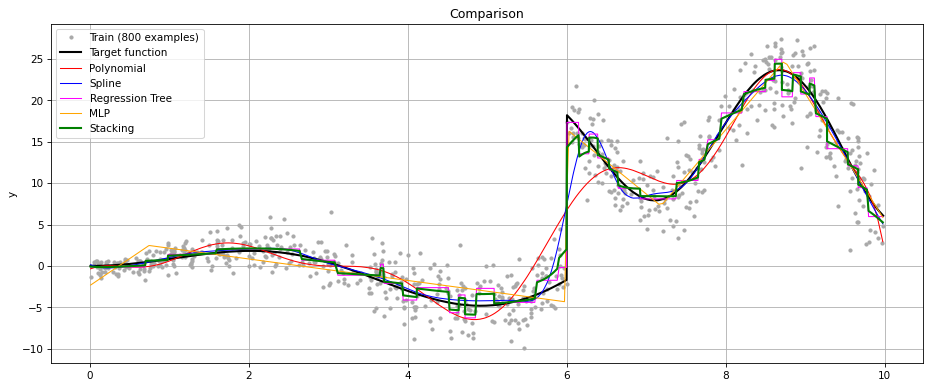

In [26]:
# Plot data
plt.figure(figsize=(15, 20))
ax1 = plt.subplot(3,1,1)
plt.plot(X_train,y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.plot(X_train, y_train_poly, '-', color = 'red', linewidth=1, label='Polynomial')
plt.plot(X_train, y_train_spline, '-', color = 'blue', linewidth=1, label='Spline')
plt.plot(X_train, y_train_regtree, '-', color = 'magenta', linewidth=1, label='Regression Tree')
plt.plot(X_train, y_train_mlp, '-', color = 'orange', linewidth=1, label='MLP')
plt.plot(X_train, y_train_stack, '-', color = 'green', linewidth=2, label='Stacking')
plt.grid()
plt.legend()
plt.title('Comparison')
plt.ylabel('y')

#### Stacking no sirve para bajar el error muchísimo.

## 8. Stacking generalization

Slow !!

In [27]:
# we use the same set of models to be stacked

stacked_genreg = StackingRegressor(
    estimators = estimators,
    #final_estimator=RandomForestRegressor(n_estimators=20, random_state=999)
    final_estimator = LinearRegression()
)

stacked_genreg = stacked_genreg.fit(X_train, y_train)
stacked_genreg



#### Lo nuevo es la regresion lineal del final.
##### Combinamos linealmente las funciones base (las nuevas funciones bases son el polinomoi, el spline, etc.)

/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
7200 fits failed out of a total of 64800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7200 fits failed with the following error:
Traceback (most recent call last):
  File "/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/envs/ML2

StackingRegressor(estimators=[('poly',
                               Pipeline(steps=[('polynomialfeatures',
                                                PolynomialFeatures(degree=15)),
                                               ('ridge', Ridge(alpha=0.001))])),
                              ('spline',
                               Pipeline(steps=[('splinetransformer',
                                                SplineTransformer(n_knots=25)),
                                               ('ridge', Ridge(alpha=0.001))])),
                              ('regtree',
                               Pipeline(steps=[('gridsearchcv',
                                                GridSearchCV(cv=10,
                                                             estimator=Pipeline(steps=[('DT',
                                                                                        Decisio...
       0.045, 0.046, 0.047, 0.048, 0.049, 0.05 , 0.051, 0.052, 0.053,
       0.054, 0.055, 0.056, 0.057, 0.058, 0.059, 0.06 , 0.061, 0.062,
       0.063, 0.064, 0.065, 0.066, 0.067, 0.068, 0.069, 0.07 , 0.071,
       0.072, 0.073, 0.074, 0.075, 0.076, 0.077, 0.078, 0.079]),
                                                                         'DT__min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                                                         'DT__min_samples_split': array([1, 2, 3, 4, 5, 6, 7, 8, 9])}))]))],
                  final_estimator=LinearRegression())

In [28]:
# coefs linear regression of the generalized stacked
# Nos sirve para sabes la importancia que le esta dando a a cada modelo.
print(stacked_genreg.final_estimator_.intercept_)
print(stacked_genreg.final_estimator_.coef_)

-1.2177564181183254
[-3.84868624e-05 -3.38291371e-03  7.61333907e-01]


MSE(TR, genstack) = 15.808658040693752
MSE(TS, genstack) = 19.123697123448146
MSE(TTS, genstack) = 18.4619465879971
MSE(TTS_true, genstack) = 12.6624107577265
MAE(TR, genstack) = 3.0229922477221693
MAE(TS, genstack) = 3.0966934414597858
MAE(TTS, genstack) = 3.1856418458247573
MAE(TTS_true, genstack) = 2.7305438550065286


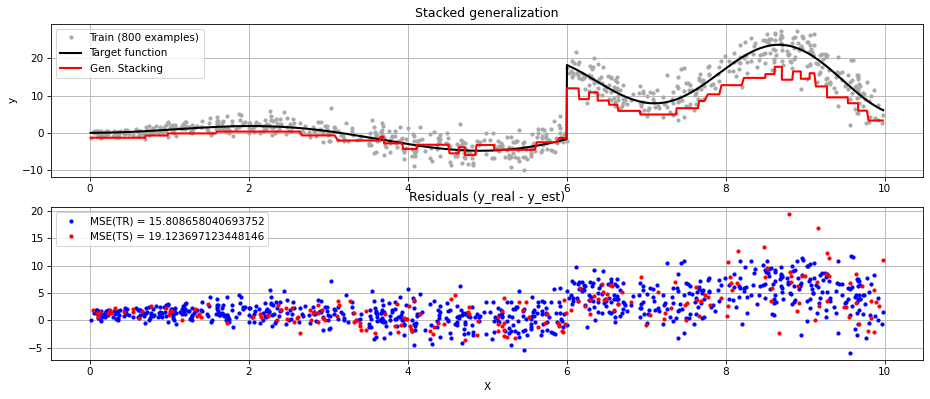

In [29]:
# estimations using the stacked models using generalization stacking with RF
y_train_genstack = stacked_genreg.predict(X_train)
y_test_genstack = stacked_genreg.predict(X_test)
y_tts_genstack = stacked_genreg.predict(X_tts)

# errors
df_err_genstack = compute_mse_mae('genstack', y_train, y_train_genstack, y_test, y_test_genstack, y_true_tts, y_tts, y_tts_genstack)

# Plot data
plt.figure(figsize=(15, 9))
ax1 = plt.subplot(3,1,1)
plt.plot(X_train,y_train,'.', color='darkgray', label=f'Train ({len(X_train)} examples)')
plt.plot(X, y_true, '-', color = 'black', linewidth=2, label='Target function')
plt.plot(X_train, y_train_genstack, '-', color = 'red', linewidth=2, label='Gen. Stacking')
plt.grid()
plt.legend()
plt.title('Stacked generalization')
plt.ylabel('y')

# plot residuals

mse_tr = df_err_genstack.loc[df_err_genstack['model_name'] == 'genstack', 'mse_tr'].values[0]
mse_ts = df_err_genstack.loc[df_err_genstack['model_name'] == 'genstack', 'mse_ts'].values[0]

plt.subplot(3,1,2, sharex = ax1)
plt.plot(X_train, y_train - y_train_genstack, '.', color = 'blue', label=f'MSE(TR) = {mse_tr}')
plt.plot(X_test, y_test - y_test_genstack, '.', color = 'red', label=f'MSE(TS) = {mse_ts}')
plt.title(f'Residuals (y_real - y_est)')
plt.legend()
plt.grid()
plt.xlabel('X')
plt.show()